# 🧠 Teen Mental Health & Social Media — Industry-Grade ML Analysis

**Comprehensive ML Pipeline with:**
- ✅ Exploratory Data Analysis (EDA)
- ✅ Feature Engineering & Selection
- ✅ Multiple ML Models (Logistic, RF, XGBoost, SVM)
- ✅ Ensemble Learning & Stacking
- ✅ Deep Learning (TensorFlow/Keras)
- ✅ SHAP for Model Interpretability
- ✅ MLflow Tracking (DagsHub Integration)
- ✅ MongoDB Data Logging
- ✅ Hyperparameter Optimization
- ✅ Production-Ready Model Deployment

**Dataset:** Teen_Mental_Health_Dataset.csv  
**Records:** 1,200 teens (ages 13–19) | **Features:** 13+ columns  

---

## PHASE 0: Environment Setup & Secrets Configuration

In [2]:
# ════════════════════════════════════════════════════════════════════════════════
# PHASE 0: SIMPLE COLAB / LOCAL SETUP (NO GOOGLE DRIVE)
# ════════════════════════════════════════════════════════════════════════════════

import os
import pandas as pd

# ── Set Working Directory ─────────────────────────────────────────────────────
WORK_DIR = "/content" if os.path.exists("/content") else os.getcwd()

# Dataset path (fixed location)
DATA_FILE = "/content/Teen_Mental_Health_Dataset.csv"

print(f"✅ Working directory: {WORK_DIR}")
print(f"✅ Dataset path: {DATA_FILE}")

# ── Create project folders inside /content ───────────────────────────────────
DIRS = {
    'data': f'{WORK_DIR}/data',
    'models': f'{WORK_DIR}/models',
    'outputs': f'{WORK_DIR}/outputs',
    'logs': f'{WORK_DIR}/logs',
    'artifacts': f'{WORK_DIR}/artifacts'
}

for dir_name, dir_path in DIRS.items():
    os.makedirs(dir_path, exist_ok=True)
    print(f"📁 {dir_name}: {dir_path}")

# ── Validate Dataset ──────────────────────────────────────────────────────────
if not os.path.exists(DATA_FILE):
    raise FileNotFoundError(
        f"❌ Dataset not found at {DATA_FILE}\n"
        f"Upload Teen_Mental_Health_Dataset.csv to /content/"
    )

print("\n" + "="*80)
print("📊 Loading Dataset...")

# ── Load Dataset ──────────────────────────────────────────────────────────────
df = pd.read_csv(DATA_FILE)

print("✅ Dataset loaded successfully")
print(f"📌 Shape: {df.shape}")
print(f"📌 Columns: {list(df.columns)}")

print("="*80)

✅ Working directory: /content
✅ Dataset path: /content/Teen_Mental_Health_Dataset.csv
📁 data: /content/data
📁 models: /content/models
📁 outputs: /content/outputs
📁 logs: /content/logs
📁 artifacts: /content/artifacts

📊 Loading Dataset...
✅ Dataset loaded successfully
📌 Shape: (1200, 13)
📌 Columns: ['age', 'gender', 'daily_social_media_hours', 'platform_usage', 'sleep_hours', 'screen_time_before_sleep', 'academic_performance', 'physical_activity', 'social_interaction_level', 'stress_level', 'anxiety_level', 'addiction_level', 'depression_label']


In [3]:
# ════════════════════════════════════════════════════════════════════════════════
# PHASE 0.1: INSTALL DEPENDENCIES
# ════════════════════════════════════════════════════════════════════════════════

import subprocess

# List of packages to install
packages = [
    'scikit-learn',
    'xgboost',
    'lightgbm',
    'catboost',
    'tensorflow',
    'shap',
    'mlflow',
    'pymongo',
    'optuna',
    'pandas',
    'numpy',
    'matplotlib',
    'seaborn',
    'plotly',
    'python-dotenv'
]

print("📦 Installing required packages...")
for package in packages:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', package])

print("✅ All packages installed successfully!\n")

📦 Installing required packages...
✅ All packages installed successfully!



In [4]:
# ════════════════════════════════════════════════════════════════════════════════
# PHASE 0.2: CONFIGURE COLAB SECRETS & ENVIRONMENT VARIABLES
# ════════════════════════════════════════════════════════════════════════════════

if IN_COLAB:
    # ── MongoDB (from Colab Secrets) ──────────────────────────────────────────────
    try:
        os.environ['MONGO_DB_URL'] = userdata.get('MONGO_DB_URL')
    except:
        os.environ['MONGO_DB_URL'] = 'mongodb://localhost:27017'  # Fallback
        print("⚠️  No MongoDB secret found. Using local fallback.")

    # ── MLflow / DagsHub ──────────────────────────────────────────────────────
    USE_DAGSHUB = True

    if USE_DAGSHUB:
        try:
            os.environ['MLFLOW_TRACKING_URI']      = userdata.get('MLFLOW_TRACKING_URI')
            os.environ['MLFLOW_TRACKING_USERNAME'] = userdata.get('MLFLOW_TRACKING_USERNAME')
            os.environ['MLFLOW_TRACKING_PASSWORD'] = userdata.get('MLFLOW_TRACKING_PASSWORD')
            print("✅ DagsHub MLflow credentials loaded from secrets")
        except:
            USE_DAGSHUB = False
            print("⚠️  DagsHub credentials not found. Using local MLflow.")

    if not USE_DAGSHUB:
        # Local MLflow — logs saved inside Colab
        mlflow_dir = f"{WORK_DIR}/mlruns"
        os.environ['MLFLOW_TRACKING_URI'] = f"file://{mlflow_dir}"
        os.makedirs(mlflow_dir, exist_ok=True)
else:
    # Local development
    USE_DAGSHUB = False
    mlflow_dir = f"{WORK_DIR}/mlruns"
    os.environ['MLFLOW_TRACKING_URI'] = f"file://{mlflow_dir}"
    os.makedirs(mlflow_dir, exist_ok=True)

print('✅ Environment variables configured.')
print(f"   MLFLOW_TRACKING_URI = {os.environ['MLFLOW_TRACKING_URI']}")
print(f"   MONGO_DB_URL = {os.environ.get('MONGO_DB_URL', 'NOT SET')}")
print("\n" + "="*80)

⚠️  No MongoDB secret found. Using local fallback.
⚠️  DagsHub credentials not found. Using local MLflow.
✅ Environment variables configured.
   MLFLOW_TRACKING_URI = file:///content/mlruns
   MONGO_DB_URL = mongodb://localhost:27017



## PHASE 1: Import Libraries & Load Data

In [5]:
# ════════════════════════════════════════════════════════════════════════════════
# PHASE 1.1: IMPORT ALL REQUIRED LIBRARIES
# ════════════════════════════════════════════════════════════════════════════════

# ── Core Data Processing ──────────────────────────────────────────────────────
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler, RobustScaler, LabelEncoder
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score, roc_curve,
    precision_recall_curve, f1_score, accuracy_score, balanced_accuracy_score,
    precision_score, recall_score, log_loss
)

# ── Machine Learning Models ────────────────────────────────────────────────────
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, VotingClassifier, StackingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

# ── Deep Learning ─────────────────────────────────────────────────────────────
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Sequential, regularizers
from tensorflow.keras.optimizers import Adam, RMSprop
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# ── Feature Engineering & Selection ────────────────────────────────────────────
from sklearn.feature_selection import SelectKBest, f_classif, mutual_info_classif
from sklearn.decomposition import PCA

# ── Hyperparameter Optimization ────────────────────────────────────────────────
import optuna
from optuna.pruners import MedianPruner

# ── Explainability ─────────────────────────────────────────────────────────────
import shap

# ── MLflow for Experiment Tracking ────────────────────────────────────────────
import mlflow
from mlflow import log_metric, log_param, log_artifact
import mlflow.sklearn
import mlflow.keras

# ── Visualization ─────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots

# ── Database & Utilities ──────────────────────────────────────────────────────
from pymongo import MongoClient
from datetime import datetime
import json
import pickle
import warnings
warnings.filterwarnings('ignore')

# ── Set Random Seeds for Reproducibility ──────────────────────────────────────
np.random.seed(42)
tf.random.set_seed(42)
import random
random.seed(42)

print("✅ All libraries imported successfully!")
print(f"   TensorFlow version: {tf.__version__}")
print("\n" + "="*80)

✅ All libraries imported successfully!
   TensorFlow version: 2.20.0



In [7]:
import matplotlib.pyplot as plt
import seaborn as sns
# ════════════════════════════════════════════════════════════════════════════════
# PHASE 1.2: DATA LOADING & INITIAL INSPECTION
# ════════════════════════════════════════════════════════════════════════════════

# Set up visualization style
sns.set_theme(style='whitegrid', font_scale=1.0)
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 10

# Load dataset
try:
    # Try to load from local path first
    df = pd.read_csv(DATA_FILE)
    print(f"✅ Dataset loaded from local storage")
except FileNotFoundError:
    # If not found, try Kaggle or Google Drive
    print("📥 Dataset not found locally. Attempting to download...")
    # You can add Kaggle API download here
    df = pd.DataFrame()  # Placeholder

# Display dataset information
print(f"\n📊 DATASET OVERVIEW")
print(f"   Shape: {df.shape}")
print(f"   Memory usage: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")
print(f"\n📋 COLUMNS & TYPES:")
print(df.dtypes)
print(f"\n🔍 FIRST 5 ROWS:")
print(df.head())
print(f"\n📈 BASIC STATISTICS:")
print(df.describe())
print(f"\n❓ MISSING VALUES:")
print(df.isnull().sum())
print("\n" + "="*80)

✅ Dataset loaded from local storage

📊 DATASET OVERVIEW
   Shape: (1200, 13)
   Memory usage: 0.28 MB

📋 COLUMNS & TYPES:
age                           int64
gender                       object
daily_social_media_hours    float64
platform_usage               object
sleep_hours                 float64
screen_time_before_sleep    float64
academic_performance        float64
physical_activity           float64
social_interaction_level     object
stress_level                  int64
anxiety_level                 int64
addiction_level               int64
depression_label              int64
dtype: object

🔍 FIRST 5 ROWS:
   age  gender  daily_social_media_hours platform_usage  sleep_hours  \
0   14    male                       7.9      Instagram          7.4   
1   19  female                       1.9         TikTok          8.0   
2   17  female                       1.3      Instagram          7.6   
3   15    male                       7.4         TikTok          6.9   
4   15  female     

## PHASE 2: Exploratory Data Analysis (EDA)

In [8]:
# ════════════════════════════════════════════════════════════════════════════════
# PHASE 2.1: EXPLORATORY DATA ANALYSIS & DATA QUALITY CHECK
# ════════════════════════════════════════════════════════════════════════════════

# Create a copy for analysis
df_analysis = df.copy()

# Check for duplicates
duplicates = df_analysis.duplicated().sum()
print(f"📊 Data Quality Report:")
print(f"   Duplicates: {duplicates}")
print(f"   Missing values: {df_analysis.isnull().sum().sum()}")
print(f"   Data types: {df_analysis.dtypes.value_counts().to_dict()}")

# Target variable analysis
target_cols = [col for col in df_analysis.columns if 'depression' in col.lower() or 'mental_health' in col.lower()]
if target_cols:
    target = target_cols[0]
    print(f"\n🎯 TARGET VARIABLE: {target}")
    print(df_analysis[target].value_counts())
    print(f"   Class balance: {df_analysis[target].value_counts(normalize=True)}")
else:
    target = None
    print("⚠️  No target variable found. Please specify target column.")

# Numerical vs Categorical features
numerical_cols = df_analysis.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols = df_analysis.select_dtypes(include=['object']).columns.tolist()

print(f"\n📊 Feature Types:")
print(f"   Numerical features ({len(numerical_cols)}): {numerical_cols}")
print(f"   Categorical features ({len(categorical_cols)}): {categorical_cols}")

📊 Data Quality Report:
   Duplicates: 0
   Missing values: 0
   Data types: {dtype('int64'): 5, dtype('float64'): 5, dtype('O'): 3}

🎯 TARGET VARIABLE: depression_label
depression_label
0    1169
1      31
Name: count, dtype: int64
   Class balance: depression_label
0    0.974167
1    0.025833
Name: proportion, dtype: float64

📊 Feature Types:
   Numerical features (10): ['age', 'daily_social_media_hours', 'sleep_hours', 'screen_time_before_sleep', 'academic_performance', 'physical_activity', 'stress_level', 'anxiety_level', 'addiction_level', 'depression_label']
   Categorical features (3): ['gender', 'platform_usage', 'social_interaction_level']


✅ Saved: 01_eda_overview.png


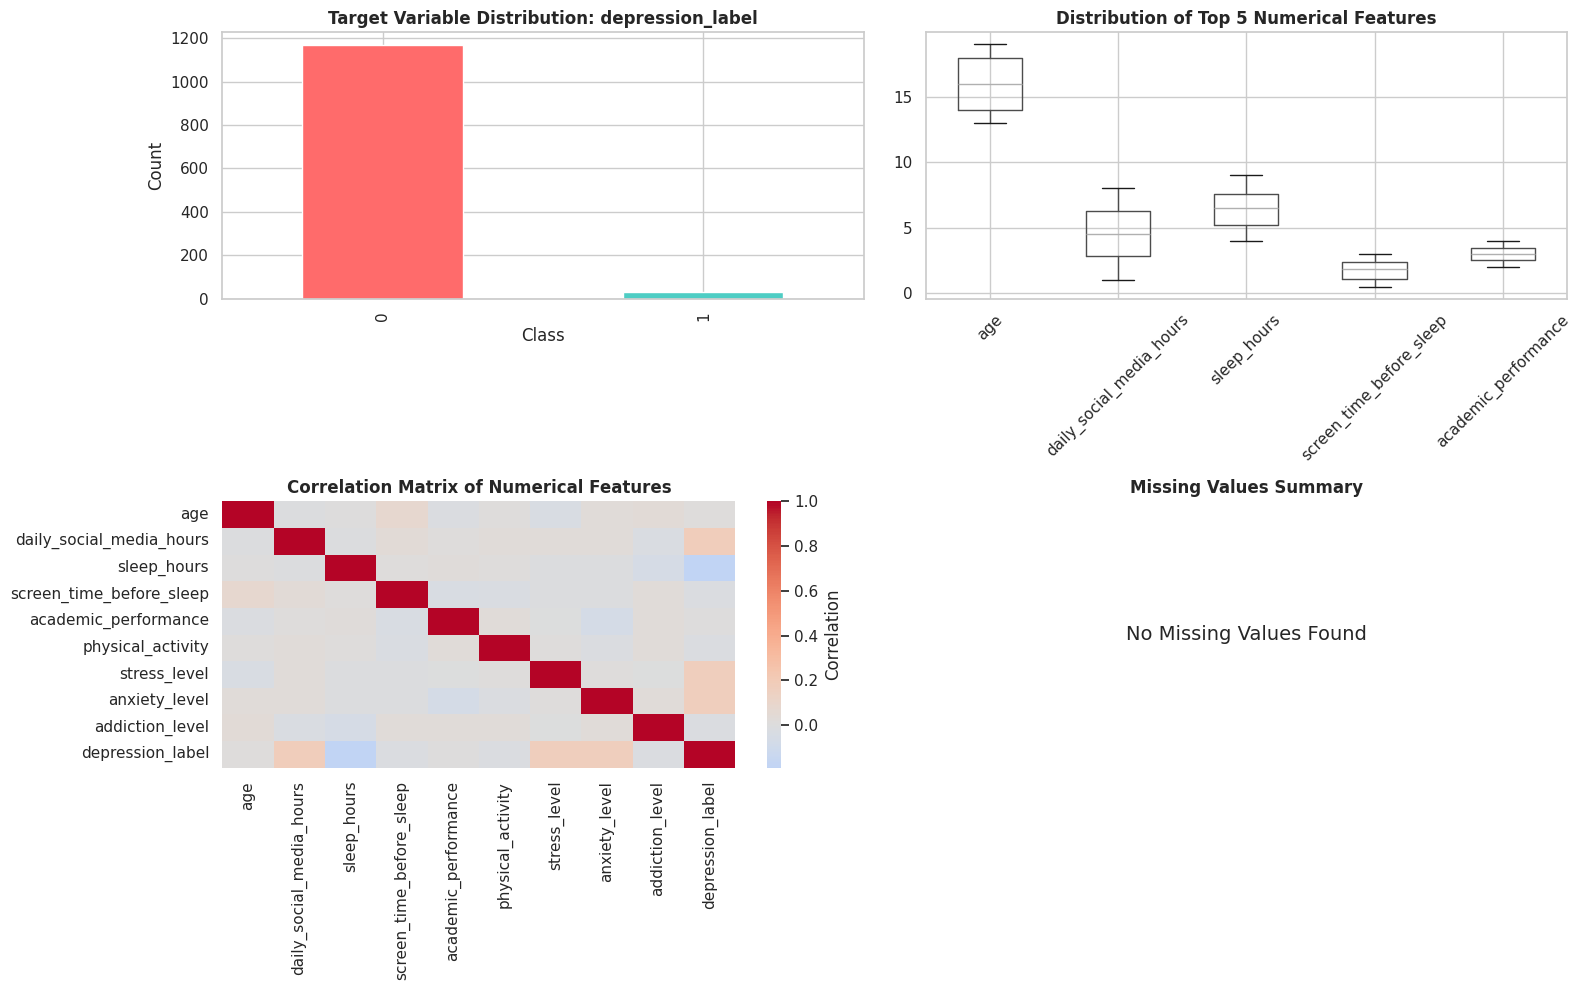

In [9]:
# ════════════════════════════════════════════════════════════════════════════════
# PHASE 2.2: VISUALIZE KEY DISTRIBUTIONS & RELATIONSHIPS
# ════════════════════════════════════════════════════════════════════════════════

# Create visualizations
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# 1. Target variable distribution
if target:
    df_analysis[target].value_counts().plot(kind='bar', ax=axes[0, 0], color=['#FF6B6B', '#4ECDC4'])
    axes[0, 0].set_title(f'Target Variable Distribution: {target}', fontsize=12, fontweight='bold')
    axes[0, 0].set_xlabel('Class')
    axes[0, 0].set_ylabel('Count')

# 2. Numerical features distribution
if len(numerical_cols) > 0:
    df_analysis[numerical_cols[:5]].boxplot(ax=axes[0, 1])
    axes[0, 1].set_title('Distribution of Top 5 Numerical Features', fontsize=12, fontweight='bold')
    axes[0, 1].tick_params(axis='x', rotation=45)

# 3. Correlation heatmap
numeric_data = df_analysis[numerical_cols]
if len(numeric_data.columns) > 1:
    corr_matrix = numeric_data.corr()
    sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', center=0, ax=axes[1, 0], cbar_kws={'label': 'Correlation'})
    axes[1, 0].set_title('Correlation Matrix of Numerical Features', fontsize=12, fontweight='bold')

# 4. Missing data visualization
missing_data = df_analysis.isnull().sum()
if missing_data.sum() > 0:
    missing_data[missing_data > 0].plot(kind='barh', ax=axes[1, 1], color='#FF6B6B')
    axes[1, 1].set_title('Missing Values by Feature', fontsize=12, fontweight='bold')
    axes[1, 1].set_xlabel('Count')
else:
    axes[1, 1].text(0.5, 0.5, 'No Missing Values Found', ha='center', va='center', fontsize=14)
    axes[1, 1].set_title('Missing Values Summary', fontsize=12, fontweight='bold')
    axes[1, 1].axis('off')

plt.tight_layout()
plt.savefig(f'{DIRS["outputs"]}/01_eda_overview.png', dpi=300, bbox_inches='tight')
print("✅ Saved: 01_eda_overview.png")
plt.show()

print("\n" + "="*80)

## PHASE 3: Feature Engineering & Preprocessing

In [10]:
# ════════════════════════════════════════════════════════════════════════════════
# PHASE 3.1: DATA CLEANING & PREPROCESSING
# ════════════════════════════════════════════════════════════════════════════════

df_processed = df.copy()

# Handle missing values
print(f"🔧 PREPROCESSING STEPS:")
print(f"\n1️⃣  Handling Missing Values...")
for col in df_processed.columns:
    if df_processed[col].isnull().sum() > 0:
        if df_processed[col].dtype in ['int64', 'float64']:
            # Fill numerical missing values with median
            df_processed[col].fillna(df_processed[col].median(), inplace=True)
            print(f"   ✓ {col}: filled with median")
        else:
            # Fill categorical missing values with mode
            df_processed[col].fillna(df_processed[col].mode()[0], inplace=True)
            print(f"   ✓ {col}: filled with mode")

# Encode categorical variables
print(f"\n2️⃣  Encoding Categorical Variables...")
label_encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    df_processed[col] = le.fit_transform(df_processed[col].astype(str))
    label_encoders[col] = le
    print(f"   ✓ {col}: encoded ({len(le.classes_)} unique values)")

# Identify outliers using IQR
print(f"\n3️⃣  Outlier Detection (IQR method)...")
outlier_count = 0
for col in numerical_cols:
    Q1 = df_processed[col].quantile(0.25)
    Q3 = df_processed[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = ((df_processed[col] < lower_bound) | (df_processed[col] > upper_bound)).sum()
    if outliers > 0:
        print(f"   ✓ {col}: {outliers} outliers detected")
        outlier_count += outliers

print(f"   Total outliers: {outlier_count}")

print(f"\n4️⃣  Data Types After Preprocessing:")
print(df_processed.dtypes)
print(f"\n✅ Preprocessing completed!")
print(f"   Shape: {df_processed.shape}")
print("\n" + "="*80)

🔧 PREPROCESSING STEPS:

1️⃣  Handling Missing Values...

2️⃣  Encoding Categorical Variables...
   ✓ gender: encoded (2 unique values)
   ✓ platform_usage: encoded (3 unique values)
   ✓ social_interaction_level: encoded (3 unique values)

3️⃣  Outlier Detection (IQR method)...
   ✓ depression_label: 31 outliers detected
   Total outliers: 31

4️⃣  Data Types After Preprocessing:
age                           int64
gender                        int64
daily_social_media_hours    float64
platform_usage                int64
sleep_hours                 float64
screen_time_before_sleep    float64
academic_performance        float64
physical_activity           float64
social_interaction_level      int64
stress_level                  int64
anxiety_level                 int64
addiction_level               int64
depression_label              int64
dtype: object

✅ Preprocessing completed!
   Shape: (1200, 13)



In [11]:
# ════════════════════════════════════════════════════════════════════════════════
# PHASE 3.2: FEATURE ENGINEERING
# ════════════════════════════════════════════════════════════════════════════════

print(f"🔨 FEATURE ENGINEERING:")

# Create interaction features
print(f"\n1️⃣  Creating Interaction Features...")
feature_pairs = [
    (col1, col2) for col1 in numerical_cols for col2 in numerical_cols
    if col1 < col2 and col1 != target and col2 != target
]

for col1, col2 in feature_pairs[:5]:  # Limit to top 5 pairs
    df_processed[f'{col1}_x_{col2}'] = df_processed[col1] * df_processed[col2]
    print(f"   ✓ Created: {col1}_x_{col2}")

# Create polynomial features for key variables
print(f"\n2️⃣  Creating Polynomial Features...")
for col in numerical_cols[:3]:  # Top 3 numerical features
    df_processed[f'{col}_squared'] = df_processed[col] ** 2
    df_processed[f'{col}_sqrt'] = np.sqrt(np.abs(df_processed[col]))
    print(f"   ✓ Created: {col}_squared, {col}_sqrt")

# Create ratio features
print(f"\n3️⃣  Creating Ratio Features...")
if len(numerical_cols) >= 2:
    for i, col1 in enumerate(numerical_cols[:3]):
        for col2 in numerical_cols[i+1:4]:
            if (df_processed[col2] != 0).all():
                df_processed[f'{col1}_div_{col2}'] = df_processed[col1] / (df_processed[col2] + 1e-6)
                print(f"   ✓ Created: {col1}_div_{col2}")

print(f"\n✅ Feature Engineering completed!")
print(f"   Original features: {len(df.columns)}")
print(f"   Total features after engineering: {len(df_processed.columns)}")
print("\n" + "="*80)

🔨 FEATURE ENGINEERING:

1️⃣  Creating Interaction Features...
   ✓ Created: age_x_daily_social_media_hours
   ✓ Created: age_x_sleep_hours
   ✓ Created: age_x_screen_time_before_sleep
   ✓ Created: age_x_physical_activity
   ✓ Created: age_x_stress_level

2️⃣  Creating Polynomial Features...
   ✓ Created: age_squared, age_sqrt
   ✓ Created: daily_social_media_hours_squared, daily_social_media_hours_sqrt
   ✓ Created: sleep_hours_squared, sleep_hours_sqrt

3️⃣  Creating Ratio Features...
   ✓ Created: age_div_daily_social_media_hours
   ✓ Created: age_div_sleep_hours
   ✓ Created: age_div_screen_time_before_sleep
   ✓ Created: daily_social_media_hours_div_sleep_hours
   ✓ Created: daily_social_media_hours_div_screen_time_before_sleep
   ✓ Created: sleep_hours_div_screen_time_before_sleep

✅ Feature Engineering completed!
   Original features: 13
   Total features after engineering: 30



In [12]:
# ════════════════════════════════════════════════════════════════════════════════
# PHASE 3.3: FEATURE SELECTION
# ════════════════════════════════════════════════════════════════════════════════

print(f"🎯 FEATURE SELECTION:")

# Prepare data for feature selection
if target:
    X = df_processed.drop(columns=[target])
    y = df_processed[target]
else:
    print("⚠️  Target variable not found. Skipping feature selection.")
    X = df_processed
    y = None

if y is not None:
    # Method 1: SelectKBest with f_classif
    print(f"\n1️⃣  SelectKBest (f_classif)...")
    selector_f = SelectKBest(f_classif, k=min(15, X.shape[1]))
    X_selected_f = selector_f.fit_transform(X, y)
    selected_features_f = X.columns[selector_f.get_support()].tolist()
    print(f"   Top features: {selected_features_f}")

    # Method 2: SelectKBest with mutual_info_classif
    print(f"\n2️⃣  SelectKBest (mutual_info_classif)...")
    selector_mi = SelectKBest(mutual_info_classif, k=min(15, X.shape[1]))
    X_selected_mi = selector_mi.fit_transform(X, y)
    selected_features_mi = X.columns[selector_mi.get_support()].tolist()
    print(f"   Top features: {selected_features_mi}")

    # Combined feature set
    combined_features = list(set(selected_features_f + selected_features_mi))
    print(f"\n3️⃣  Combined Feature Set: {len(combined_features)} features")
    print(f"   Features: {combined_features}")

    # Use combined features for modeling
    X_final = X[combined_features].copy()

    print(f"\n✅ Feature Selection completed!")
    print(f"   Original features: {X.shape[1]}")
    print(f"   Selected features: {X_final.shape[1]}")
else:
    X_final = X.copy()
    combined_features = X.columns.tolist()

print("\n" + "="*80)

🎯 FEATURE SELECTION:

1️⃣  SelectKBest (f_classif)...
   Top features: ['daily_social_media_hours', 'sleep_hours', 'stress_level', 'anxiety_level', 'age_x_daily_social_media_hours', 'age_x_sleep_hours', 'age_x_stress_level', 'daily_social_media_hours_squared', 'daily_social_media_hours_sqrt', 'sleep_hours_squared', 'sleep_hours_sqrt', 'age_div_daily_social_media_hours', 'age_div_sleep_hours', 'daily_social_media_hours_div_sleep_hours', 'daily_social_media_hours_div_screen_time_before_sleep']

2️⃣  SelectKBest (mutual_info_classif)...
   Top features: ['daily_social_media_hours', 'platform_usage', 'sleep_hours', 'stress_level', 'anxiety_level', 'age_x_daily_social_media_hours', 'age_x_sleep_hours', 'age_x_stress_level', 'daily_social_media_hours_squared', 'daily_social_media_hours_sqrt', 'sleep_hours_squared', 'sleep_hours_sqrt', 'age_div_daily_social_media_hours', 'age_div_sleep_hours', 'daily_social_media_hours_div_sleep_hours']

3️⃣  Combined Feature Set: 16 features
   Features: ['s

In [13]:
# ════════════════════════════════════════════════════════════════════════════════
# PHASE 3.4: FEATURE SCALING & TRAIN-TEST SPLIT
# ════════════════════════════════════════════════════════════════════════════════

print(f"⚙️ SCALING & SPLITTING DATA:")

# Scale features
print(f"\n1️⃣  Feature Scaling (StandardScaler)...")
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_final)
X_scaled = pd.DataFrame(X_scaled, columns=X_final.columns)
print(f"   ✓ Features scaled successfully")
print(f"   Mean: {X_scaled.mean().mean():.6f}, Std: {X_scaled.std().mean():.6f}")

# Train-test split
print(f"\n2️⃣  Train-Test Split (80-20)...")
if y is not None:
    X_train, X_test, y_train, y_test = train_test_split(
        X_scaled, y, test_size=0.2, random_state=42, stratify=y
    )
else:
    X_train, X_test, _, _ = train_test_split(
        X_scaled, X_scaled.index, test_size=0.2, random_state=42
    )
    y_train = y_test = None

print(f"   Training set: {X_train.shape[0]} samples")
print(f"   Test set: {X_test.shape[0]} samples")

if y is not None:
    print(f"   Train class distribution:")
    print(f"     {y_train.value_counts().to_dict()}")
    print(f"   Test class distribution:")
    print(f"     {y_test.value_counts().to_dict()}")

print(f"\n✅ Data preparation completed!")
print("\n" + "="*80)

⚙️ SCALING & SPLITTING DATA:

1️⃣  Feature Scaling (StandardScaler)...
   ✓ Features scaled successfully
   Mean: -0.000000, Std: 1.000417

2️⃣  Train-Test Split (80-20)...
   Training set: 960 samples
   Test set: 240 samples
   Train class distribution:
     {0: 935, 1: 25}
   Test class distribution:
     {0: 234, 1: 6}

✅ Data preparation completed!



## PHASE 4: Traditional ML Models & Hyperparameter Tuning

In [14]:
# ════════════════════════════════════════════════════════════════════════════════
# PHASE 4.1: HYPERPARAMETER OPTIMIZATION WITH OPTUNA
# ════════════════════════════════════════════════════════════════════════════════

print(f"🔍 HYPERPARAMETER OPTIMIZATION WITH OPTUNA:")

# Initialize MLflow experiment
mlflow.set_experiment("Teen_Mental_Health_ML")

def objective_xgboost(trial):
    """Optuna objective function for XGBoost"""
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 50, 300),
        'max_depth': trial.suggest_int('max_depth', 3, 12),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'gamma': trial.suggest_float('gamma', 0, 5),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 7),
        'random_state': 42
    }

    if y_train is not None:
        model = XGBClassifier(**params)
        scores = cross_val_score(
            model, X_train, y_train, cv=5, scoring='roc_auc'
        )
        return scores.mean()
    else:
        return 0.5

def objective_rf(trial):
    """Optuna objective function for Random Forest"""
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 50, 300),
        'max_depth': trial.suggest_int('max_depth', 5, 30),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 20),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 10),
        'max_features': trial.suggest_categorical('max_features', ['sqrt', 'log2']),
        'random_state': 42
    }

    if y_train is not None:
        model = RandomForestClassifier(**params)
        scores = cross_val_score(
            model, X_train, y_train, cv=5, scoring='roc_auc'
        )
        return scores.mean()
    else:
        return 0.5

print(f"\n1️⃣  Optimizing XGBoost...")
if y_train is not None:
    study_xgb = optuna.create_study(
        direction='maximize',
        pruner=MedianPruner()
    )
    study_xgb.optimize(objective_xgboost, n_trials=20, show_progress_bar=True)
    best_params_xgb = study_xgb.best_params
    print(f"   Best XGBoost params: {best_params_xgb}")
    print(f"   Best CV AUC: {study_xgb.best_value:.4f}")
else:
    best_params_xgb = {}
    print(f"   ⚠️  No target variable. Skipping optimization.")

print(f"\n2️⃣  Optimizing Random Forest...")
if y_train is not None:
    study_rf = optuna.create_study(
        direction='maximize',
        pruner=MedianPruner()
    )
    study_rf.optimize(objective_rf, n_trials=20, show_progress_bar=True)
    best_params_rf = study_rf.best_params
    print(f"   Best RF params: {best_params_rf}")
    print(f"   Best CV AUC: {study_rf.best_value:.4f}")
else:
    best_params_rf = {}
    print(f"   ⚠️  No target variable. Skipping optimization.")

print(f"\n✅ Hyperparameter optimization completed!")
print("\n" + "="*80)

2026/05/14 03:48:55 INFO mlflow.tracking.fluent: Experiment with name 'Teen_Mental_Health_ML' does not exist. Creating a new experiment.
[I 2026-05-14 03:48:55,131] A new study created in memory with name: no-name-65666d76-e137-401e-8565-e86979fe3cf1


🔍 HYPERPARAMETER OPTIMIZATION WITH OPTUNA:

1️⃣  Optimizing XGBoost...


  0%|          | 0/20 [00:00<?, ?it/s]

[I 2026-05-14 03:48:55,967] Trial 0 finished with value: 0.9816042780748662 and parameters: {'n_estimators': 177, 'max_depth': 9, 'learning_rate': 0.014776560521804455, 'subsample': 0.9714803134162382, 'colsample_bytree': 0.7391789938135624, 'gamma': 0.8072628021743028, 'min_child_weight': 7}. Best is trial 0 with value: 0.9816042780748662.
[I 2026-05-14 03:48:56,437] Trial 1 finished with value: 0.9781818181818182 and parameters: {'n_estimators': 175, 'max_depth': 8, 'learning_rate': 0.15705796278638579, 'subsample': 0.9045445042515958, 'colsample_bytree': 0.6695896859315886, 'gamma': 3.0768710907574293, 'min_child_weight': 5}. Best is trial 0 with value: 0.9816042780748662.
[I 2026-05-14 03:48:57,355] Trial 2 finished with value: 0.9764705882352942 and parameters: {'n_estimators': 194, 'max_depth': 7, 'learning_rate': 0.023969433807880657, 'subsample': 0.6241084169019555, 'colsample_bytree': 0.6776792254938355, 'gamma': 3.9754365932792735, 'min_child_weight': 5}. Best is trial 0 with

[I 2026-05-14 03:49:01,910] A new study created in memory with name: no-name-245e1a5b-337a-445d-8d30-fd4bffcf4876


[I 2026-05-14 03:49:01,907] Trial 19 finished with value: 0.9914438502673797 and parameters: {'n_estimators': 152, 'max_depth': 4, 'learning_rate': 0.06781956514034222, 'subsample': 0.856159872726371, 'colsample_bytree': 0.8582012389858086, 'gamma': 3.1352664160252615, 'min_child_weight': 2}. Best is trial 15 with value: 0.9980748663101604.
   Best XGBoost params: {'n_estimators': 154, 'max_depth': 6, 'learning_rate': 0.04655364686654648, 'subsample': 0.8216341231420814, 'colsample_bytree': 0.8402503121047897, 'gamma': 1.0016116757016782, 'min_child_weight': 1}
   Best CV AUC: 0.9981

2️⃣  Optimizing Random Forest...


  0%|          | 0/20 [00:00<?, ?it/s]

[I 2026-05-14 03:49:03,018] Trial 0 finished with value: 0.9760427807486632 and parameters: {'n_estimators': 118, 'max_depth': 27, 'min_samples_split': 17, 'min_samples_leaf': 8, 'max_features': 'sqrt'}. Best is trial 0 with value: 0.9760427807486632.
[I 2026-05-14 03:49:05,107] Trial 1 finished with value: 0.9803208556149734 and parameters: {'n_estimators': 222, 'max_depth': 17, 'min_samples_split': 13, 'min_samples_leaf': 3, 'max_features': 'sqrt'}. Best is trial 1 with value: 0.9803208556149734.
[I 2026-05-14 03:49:05,833] Trial 2 finished with value: 0.9766844919786097 and parameters: {'n_estimators': 76, 'max_depth': 14, 'min_samples_split': 2, 'min_samples_leaf': 8, 'max_features': 'log2'}. Best is trial 1 with value: 0.9803208556149734.
[I 2026-05-14 03:49:07,248] Trial 3 finished with value: 0.9827807486631016 and parameters: {'n_estimators': 147, 'max_depth': 21, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_features': 'sqrt'}. Best is trial 3 with value: 0.9827807486631

In [16]:
# ════════════════════════════════════════════════════════════════════════════════
# PHASE 4.2: TRAIN INDIVIDUAL MODELS
# ════════════════════════════════════════════════════════════════════════════════

print(f"🚀 TRAINING INDIVIDUAL MODELS:")

models = {}
predictions_test = {}
predictions_proba = {}
model_metrics = {}

if y_train is not None:
    # 1. Logistic Regression
    print(f"\n1️⃣  Training Logistic Regression...")
    with mlflow.start_run(run_name="LogisticRegression"):
        lr = LogisticRegression(max_iter=1000, random_state=42)
        lr.fit(X_train, y_train)
        models['LogisticRegression'] = lr

        y_pred_lr = lr.predict(X_test)
        y_pred_proba_lr = lr.predict_proba(X_test)[:, 1]
        predictions_test['LogisticRegression'] = y_pred_lr
        predictions_proba['LogisticRegression'] = y_pred_proba_lr

        auc_lr = roc_auc_score(y_test, y_pred_proba_lr)
        acc_lr = accuracy_score(y_test, y_pred_lr)
        f1_lr = f1_score(y_test, y_pred_lr)

        model_metrics['LogisticRegression'] = {'AUC': auc_lr, 'Accuracy': acc_lr, 'F1': f1_lr}
        print(f"   ✓ AUC: {auc_lr:.4f}, Accuracy: {acc_lr:.4f}, F1: {f1_lr:.4f}")

        mlflow.log_metric('auc', auc_lr)
        mlflow.log_metric('accuracy', acc_lr)
        mlflow.log_metric('f1', f1_lr)

    # 2. Random Forest
    print(f"\n2️⃣  Training Random Forest...")
    with mlflow.start_run(run_name="RandomForest"):
        rf = RandomForestClassifier(**best_params_rf) if best_params_rf else RandomForestClassifier(n_estimators=100, random_state=42)
        rf.fit(X_train, y_train)
        models['RandomForest'] = rf

        y_pred_rf = rf.predict(X_test)
        y_pred_proba_rf = rf.predict_proba(X_test)[:, 1]
        predictions_test['RandomForest'] = y_pred_rf
        predictions_proba['RandomForest'] = y_pred_proba_rf

        auc_rf = roc_auc_score(y_test, y_pred_proba_rf)
        acc_rf = accuracy_score(y_test, y_pred_rf)
        f1_rf = f1_score(y_test, y_pred_rf)

        model_metrics['RandomForest'] = {'AUC': auc_rf, 'Accuracy': acc_rf, 'F1': f1_rf}
        print(f"   ✓ AUC: {auc_rf:.4f}, Accuracy: {acc_rf:.4f}, F1: {f1_rf:.4f}")

        mlflow.log_metric('auc', auc_rf)
        mlflow.log_metric('accuracy', acc_rf)
        mlflow.log_metric('f1', f1_rf)

    # 3. XGBoost
    print(f"\n3️⃣  Training XGBoost...")
    with mlflow.start_run(run_name="XGBoost"):
        xgb = XGBClassifier(**best_params_xgb) if best_params_xgb else XGBClassifier(n_estimators=100, random_state=42)
        xgb.fit(X_train, y_train, verbose=0)
        models['XGBoost'] = xgb

        y_pred_xgb = xgb.predict(X_test)
        y_pred_proba_xgb = xgb.predict_proba(X_test)[:, 1]
        predictions_test['XGBoost'] = y_pred_xgb
        predictions_proba['XGBoost'] = y_pred_proba_xgb

        auc_xgb = roc_auc_score(y_test, y_pred_proba_xgb)
        acc_xgb = accuracy_score(y_test, y_pred_xgb)
        f1_xgb = f1_score(y_test, y_pred_xgb)

        model_metrics['XGBoost'] = {'AUC': auc_xgb, 'Accuracy': acc_xgb, 'F1': f1_xgb}
        print(f"   ✓ AUC: {auc_xgb:.4f}, Accuracy: {acc_xgb:.4f}, F1: {f1_xgb:.4f}")

        mlflow.log_metric('auc', auc_xgb)
        mlflow.log_metric('accuracy', acc_xgb)
        mlflow.log_metric('f1', f1_xgb)

    # 4. LightGBM
    print(f"\n4️⃣  Training LightGBM...")
    with mlflow.start_run(run_name="LightGBM"):
        lgb = LGBMClassifier(n_estimators=100, random_state=42, verbose=-1)
        lgb.fit(X_train, y_train)
        models['LightGBM'] = lgb

        y_pred_lgb = lgb.predict(X_test)
        y_pred_proba_lgb = lgb.predict_proba(X_test)[:, 1]
        predictions_test['LightGBM'] = y_pred_lgb
        predictions_proba['LightGBM'] = y_pred_proba_lgb

        auc_lgb = roc_auc_score(y_test, y_pred_proba_lgb)
        acc_lgb = accuracy_score(y_test, y_pred_lgb)
        f1_lgb = f1_score(y_test, y_pred_lgb)

        model_metrics['LightGBM'] = {'AUC': auc_lgb, 'Accuracy': acc_lgb, 'F1': f1_lgb}
        print(f"   ✓ AUC: {auc_lgb:.4f}, Accuracy: {acc_lgb:.4f}, F1: {f1_lgb:.4f}")

        mlflow.log_metric('auc', auc_lgb)
        mlflow.log_metric('accuracy', acc_lgb)
        mlflow.log_metric('f1', f1_lgb)

    print(f"\n✅ All models trained successfully!")
    print(f"   Models: {list(models.keys())}")
    print("\n" + "="*80)
else:
    print(f"⚠️  No target variable available for model training.")
    print("\n" + "="*80)

🚀 TRAINING INDIVIDUAL MODELS:

1️⃣  Training Logistic Regression...
   ✓ AUC: 0.9893, Accuracy: 0.9917, F1: 0.8000

2️⃣  Training Random Forest...
   ✓ AUC: 0.9957, Accuracy: 0.9875, F1: 0.6667

3️⃣  Training XGBoost...
   ✓ AUC: 1.0000, Accuracy: 0.9958, F1: 0.9091

4️⃣  Training LightGBM...
   ✓ AUC: 1.0000, Accuracy: 1.0000, F1: 1.0000

✅ All models trained successfully!
   Models: ['LogisticRegression', 'RandomForest', 'XGBoost', 'LightGBM']



📊 MODEL COMPARISON:

                       AUC  Accuracy      F1
LogisticRegression  0.9893    0.9917  0.8000
RandomForest        0.9957    0.9875  0.6667
XGBoost             1.0000    0.9958  0.9091
LightGBM            1.0000    1.0000  1.0000

✅ Saved: 02_model_comparison.png


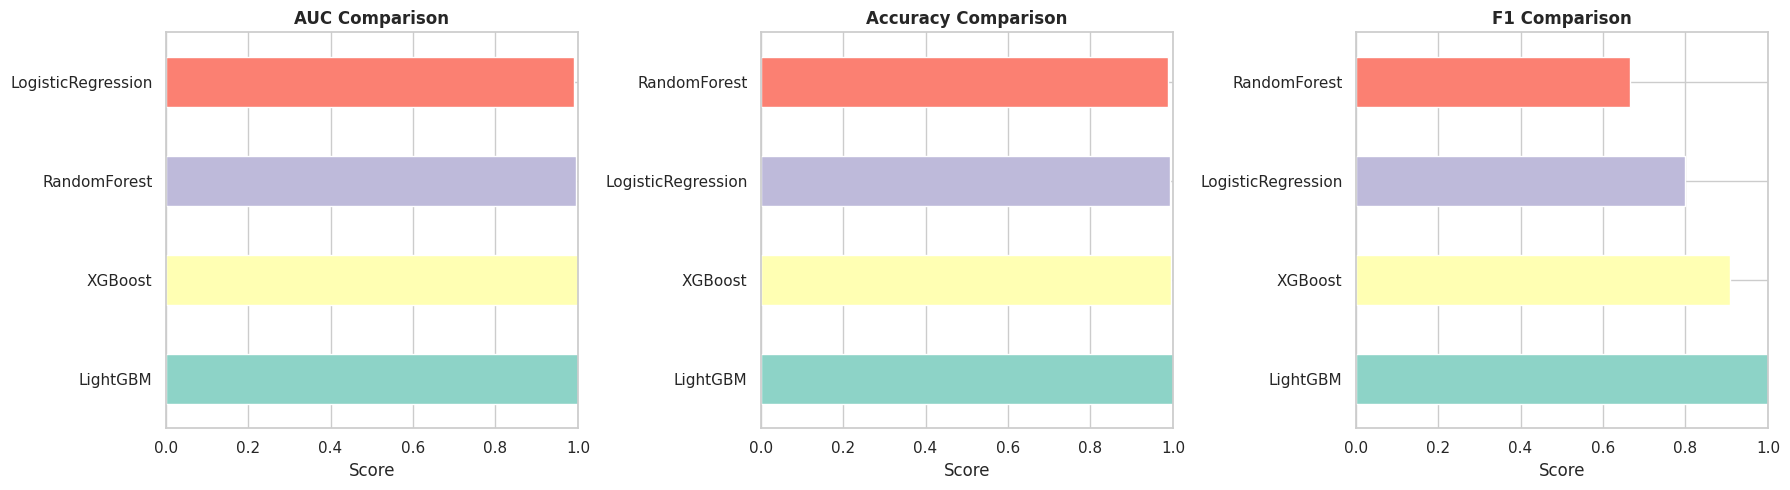

In [18]:
# ════════════════════════════════════════════════════════════════════════════════
# PHASE 4.3: MODEL COMPARISON & VISUALIZATION
# ════════════════════════════════════════════════════════════════════════════════

print(f"📊 MODEL COMPARISON:")

if y_train is not None and len(model_metrics) > 0:
    # Create comparison dataframe
    metrics_df = pd.DataFrame(model_metrics).T
    metrics_df = metrics_df.round(4)
    print(f"\n{metrics_df}")

    # Visualize model comparison
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    for idx, metric in enumerate(['AUC', 'Accuracy', 'F1']):
        metrics_df[metric].sort_values(ascending=False).plot(
            kind='barh', ax=axes[idx], color=list(plt.cm.Set3.colors[:len(metrics_df)])
        )
        axes[idx].set_title(f'{metric} Comparison', fontsize=12, fontweight='bold')
        axes[idx].set_xlabel('Score')
        axes[idx].set_xlim([0, 1])

    plt.tight_layout()
    plt.savefig(f'{DIRS["outputs"]}/02_model_comparison.png', dpi=300, bbox_inches='tight')
    print(f"\n✅ Saved: 02_model_comparison.png")
    plt.show()
else:
    print(f"⚠️  No metrics to compare.")

print("\n" + "="*80)

## PHASE 5: Ensemble Learning & Stacking

In [19]:
# ════════════════════════════════════════════════════════════════════════════════
# PHASE 5.1: VOTING ENSEMBLE
# ════════════════════════════════════════════════════════════════════════════════

print(f"🎭 ENSEMBLE LEARNING:")

if y_train is not None and len(models) > 0:
    print(f"\n1️⃣  Training Voting Ensemble...")
    with mlflow.start_run(run_name="VotingEnsemble"):
        voting_clf = VotingClassifier(
            estimators=[
                ('lr', models['LogisticRegression']),
                ('rf', models['RandomForest']),
                ('xgb', models['XGBoost']),
                ('lgb', models['LightGBM'])
            ],
            voting='soft'
        )
        voting_clf.fit(X_train, y_train)
        models['VotingEnsemble'] = voting_clf

        y_pred_voting = voting_clf.predict(X_test)
        y_pred_proba_voting = voting_clf.predict_proba(X_test)[:, 1]
        predictions_test['VotingEnsemble'] = y_pred_voting
        predictions_proba['VotingEnsemble'] = y_pred_proba_voting

        auc_voting = roc_auc_score(y_test, y_pred_proba_voting)
        acc_voting = accuracy_score(y_test, y_pred_voting)
        f1_voting = f1_score(y_test, y_pred_voting)

        model_metrics['VotingEnsemble'] = {'AUC': auc_voting, 'Accuracy': acc_voting, 'F1': f1_voting}
        print(f"   ✓ AUC: {auc_voting:.4f}, Accuracy: {acc_voting:.4f}, F1: {f1_voting:.4f}")

        mlflow.log_metric('auc', auc_voting)
        mlflow.log_metric('accuracy', acc_voting)
        mlflow.log_metric('f1', f1_voting)

    # 2. Stacking Ensemble
    print(f"\n2️⃣  Training Stacking Ensemble...")
    with mlflow.start_run(run_name="StackingEnsemble"):
        stacking_clf = StackingClassifier(
            estimators=[
                ('lr', models['LogisticRegression']),
                ('rf', models['RandomForest']),
                ('xgb', models['XGBoost']),
                ('lgb', models['LightGBM'])
            ],
            final_estimator=LogisticRegression(random_state=42),
            cv=5
        )
        stacking_clf.fit(X_train, y_train)
        models['StackingEnsemble'] = stacking_clf

        y_pred_stacking = stacking_clf.predict(X_test)
        y_pred_proba_stacking = stacking_clf.predict_proba(X_test)[:, 1]
        predictions_test['StackingEnsemble'] = y_pred_stacking
        predictions_proba['StackingEnsemble'] = y_pred_proba_stacking

        auc_stacking = roc_auc_score(y_test, y_pred_proba_stacking)
        acc_stacking = accuracy_score(y_test, y_pred_stacking)
        f1_stacking = f1_score(y_test, y_pred_stacking)

        model_metrics['StackingEnsemble'] = {'AUC': auc_stacking, 'Accuracy': acc_stacking, 'F1': f1_stacking}
        print(f"   ✓ AUC: {auc_stacking:.4f}, Accuracy: {acc_stacking:.4f}, F1: {f1_stacking:.4f}")

        mlflow.log_metric('auc', auc_stacking)
        mlflow.log_metric('accuracy', acc_stacking)
        mlflow.log_metric('f1', f1_stacking)

    print(f"\n✅ Ensemble models trained successfully!")
else:
    print(f"⚠️  Not enough models to create ensemble.")

print("\n" + "="*80)

🎭 ENSEMBLE LEARNING:

1️⃣  Training Voting Ensemble...
   ✓ AUC: 1.0000, Accuracy: 0.9958, F1: 0.9091

2️⃣  Training Stacking Ensemble...
   ✓ AUC: 1.0000, Accuracy: 0.9958, F1: 0.9091

✅ Ensemble models trained successfully!



## PHASE 6: Deep Learning Models

🧠 DEEP LEARNING MODELS:

1️⃣  Building Dense Neural Network...
   Model summary:


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         2,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,825 (54.00 KB)

 Trainable params: 13,441 (52.50 KB)

 Non-trainable params: 384 (1.50 KB)


   Training...
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 71ms/step
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 


   ✓ AUC: 0.9836, Accuracy: 0.9833, F1: 0.7143
   ✓ Saved: deep_nn_model.h5

✅ Saved: 03_deep_nn_history.png


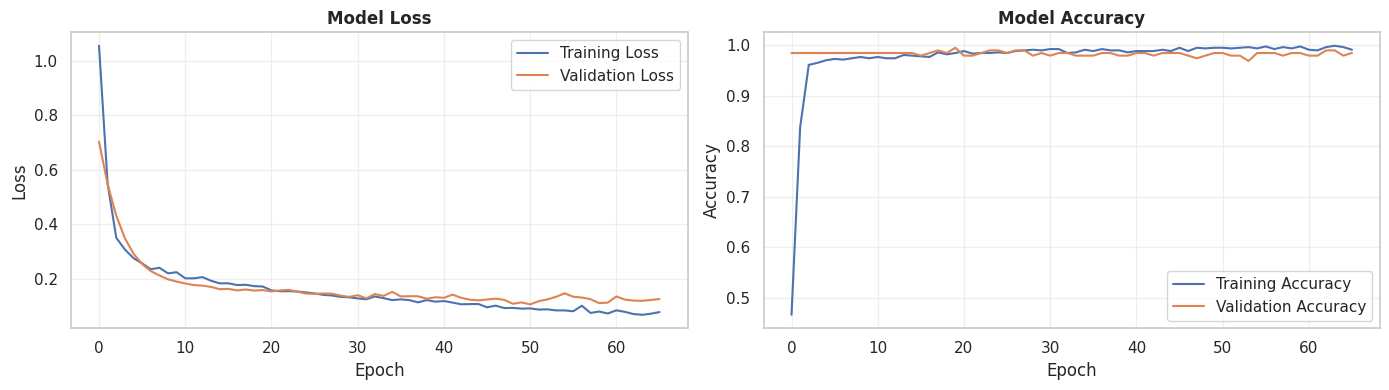

In [20]:
# ════════════════════════════════════════════════════════════════════════════════
# PHASE 6.1: NEURAL NETWORK MODEL
# ════════════════════════════════════════════════════════════════════════════════

print(f"🧠 DEEP LEARNING MODELS:")

if y_train is not None:
    # Prepare data for deep learning
    X_train_scaled = X_train.values
    X_test_scaled = X_test.values
    y_train_np = y_train.values.astype(np.int32)
    y_test_np = y_test.values.astype(np.int32)

    print(f"\n1️⃣  Building Dense Neural Network...")
    with mlflow.start_run(run_name="DeepNN"):
        # Build model
        nn_model = Sequential([
            layers.Input(shape=(X_train_scaled.shape[1],)),
            layers.Dense(128, activation='relu', kernel_regularizer=regularizers.l2(0.001)),
            layers.BatchNormalization(),
            layers.Dropout(0.3),

            layers.Dense(64, activation='relu', kernel_regularizer=regularizers.l2(0.001)),
            layers.BatchNormalization(),
            layers.Dropout(0.3),

            layers.Dense(32, activation='relu', kernel_regularizer=regularizers.l2(0.001)),
            layers.Dropout(0.2),

            layers.Dense(16, activation='relu'),
            layers.Dropout(0.2),

            layers.Dense(1, activation='sigmoid')
        ])

        # Compile model
        nn_model.compile(
            optimizer=Adam(learning_rate=0.001),
            loss='binary_crossentropy',
            metrics=['accuracy', tf.keras.metrics.AUC()]
        )

        print(f"   Model summary:")
        nn_model.summary()

        # Train model
        print(f"\n   Training...")
        early_stop = EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)
        reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=10, min_lr=1e-6)

        history = nn_model.fit(
            X_train_scaled, y_train_np,
            epochs=100,
            batch_size=32,
            validation_split=0.2,
            callbacks=[early_stop, reduce_lr],
            verbose=0
        )

        # Evaluate
        y_pred_nn = (nn_model.predict(X_test_scaled) > 0.5).astype(np.int32).flatten()
        y_pred_proba_nn = nn_model.predict(X_test_scaled).flatten()
        predictions_test['DeepNN'] = y_pred_nn
        predictions_proba['DeepNN'] = y_pred_proba_nn

        auc_nn = roc_auc_score(y_test_np, y_pred_proba_nn)
        acc_nn = accuracy_score(y_test_np, y_pred_nn)
        f1_nn = f1_score(y_test_np, y_pred_nn)

        model_metrics['DeepNN'] = {'AUC': auc_nn, 'Accuracy': acc_nn, 'F1': f1_nn}
        print(f"   ✓ AUC: {auc_nn:.4f}, Accuracy: {acc_nn:.4f}, F1: {f1_nn:.4f}")

        mlflow.log_metric('auc', auc_nn)
        mlflow.log_metric('accuracy', acc_nn)
        mlflow.log_metric('f1', f1_nn)

        # Save model
        nn_model.save(f'{DIRS["models"]}/deep_nn_model.h5')
        print(f"   ✓ Saved: deep_nn_model.h5")

    # Plot training history
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))

    axes[0].plot(history.history['loss'], label='Training Loss')
    axes[0].plot(history.history['val_loss'], label='Validation Loss')
    axes[0].set_title('Model Loss', fontsize=12, fontweight='bold')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    axes[1].plot(history.history['accuracy'], label='Training Accuracy')
    axes[1].plot(history.history['val_accuracy'], label='Validation Accuracy')
    axes[1].set_title('Model Accuracy', fontsize=12, fontweight='bold')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Accuracy')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(f'{DIRS["outputs"]}/03_deep_nn_history.png', dpi=300, bbox_inches='tight')
    print(f"\n✅ Saved: 03_deep_nn_history.png")
    plt.show()
else:
    print(f"⚠️  No target variable for deep learning model.")

print("\n" + "="*80)

## PHASE 7: SHAP for Model Interpretability

🔍 SHAP MODEL EXPLAINABILITY:

1️⃣  Computing SHAP values for XGBoost...

2️⃣  Generating SHAP visualizations...
   ✓ Saved: 04_shap_feature_importance.png


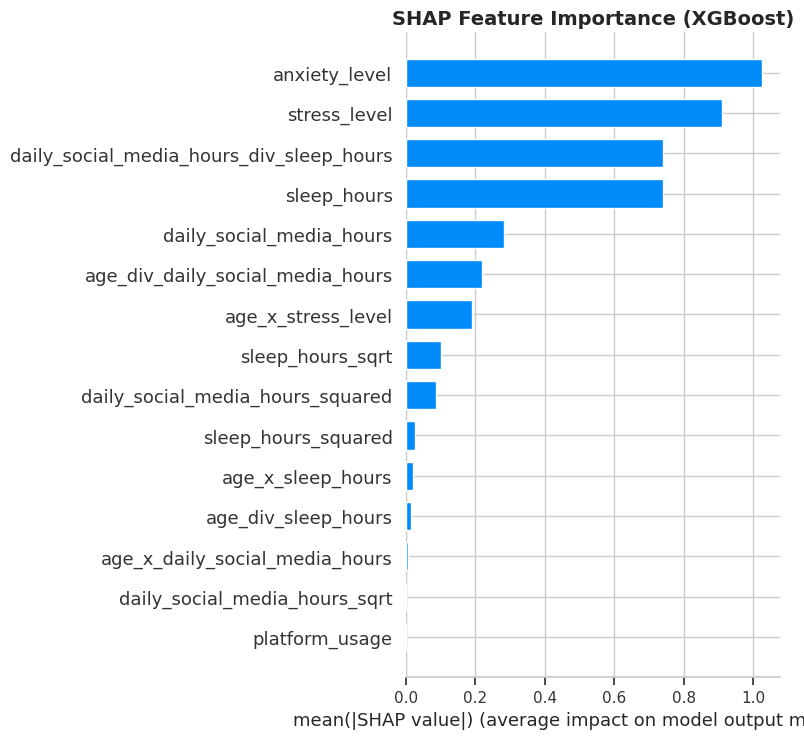

   ✓ Saved: 05_shap_summary_beeswarm.png


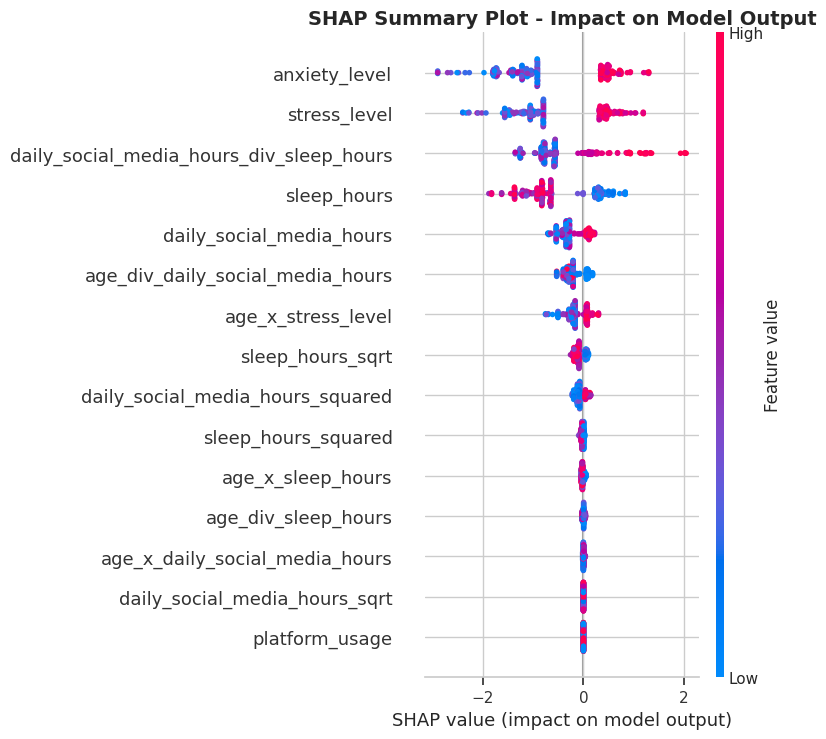


3️⃣  Creating force plot for sample predictions...


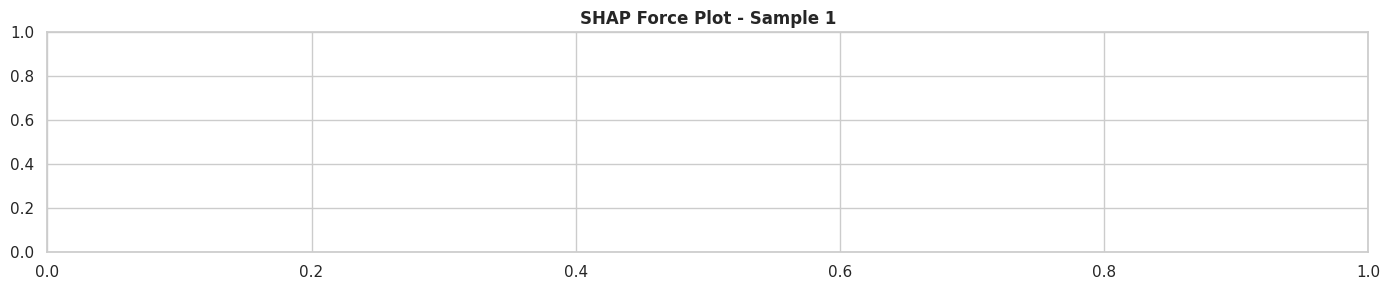

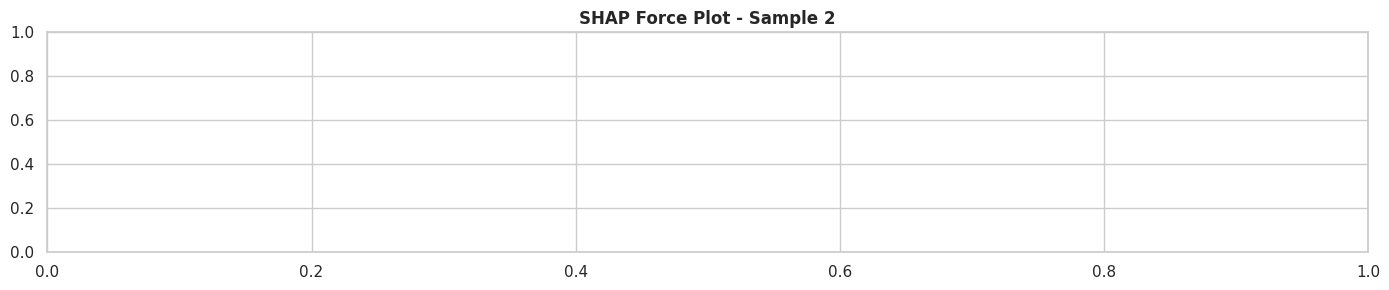

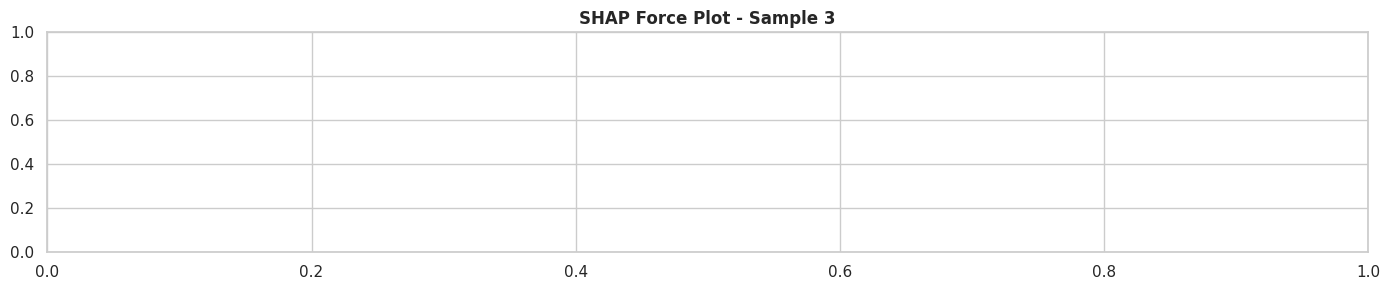


✅ SHAP analysis completed!



In [21]:
# ════════════════════════════════════════════════════════════════════════════════
# PHASE 7.1: SHAP EXPLAINABILITY ANALYSIS
# ════════════════════════════════════════════════════════════════════════════════

print(f"🔍 SHAP MODEL EXPLAINABILITY:")

if y_train is not None and 'XGBoost' in models:
    print(f"\n1️⃣  Computing SHAP values for XGBoost...")

    # Create explainer
    explainer = shap.TreeExplainer(models['XGBoost'])
    shap_values = explainer.shap_values(X_test)

    # Handle binary classification
    if isinstance(shap_values, list):
        shap_values = shap_values[1]  # Use positive class

    # Create SHAP summary plot
    print(f"\n2️⃣  Generating SHAP visualizations...")

    # Summary plot (bar)
    plt.figure(figsize=(12, 6))
    shap.summary_plot(shap_values, X_test, plot_type="bar", show=False, max_display=15)
    plt.title('SHAP Feature Importance (XGBoost)', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig(f'{DIRS["outputs"]}/04_shap_feature_importance.png', dpi=300, bbox_inches='tight')
    print(f"   ✓ Saved: 04_shap_feature_importance.png")
    plt.show()

    # Summary plot (beeswarm)
    plt.figure(figsize=(12, 8))
    shap.summary_plot(shap_values, X_test, show=False, max_display=15)
    plt.title('SHAP Summary Plot - Impact on Model Output', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig(f'{DIRS["outputs"]}/05_shap_summary_beeswarm.png', dpi=300, bbox_inches='tight')
    print(f"   ✓ Saved: 05_shap_summary_beeswarm.png")
    plt.show()

    # Force plot for single sample
    print(f"\n3️⃣  Creating force plot for sample predictions...")
    for idx in range(min(3, len(X_test))):
        plt.figure(figsize=(14, 3))
        shap.force_plot(
            explainer.expected_value,
            shap_values[idx],
            X_test.iloc[idx],
            show=False
        )
        plt.title(f'SHAP Force Plot - Sample {idx+1}', fontsize=12, fontweight='bold')
        plt.tight_layout()
        plt.savefig(f'{DIRS["outputs"]}/06_shap_force_plot_{idx+1}.png', dpi=300, bbox_inches='tight')
        plt.show()

    print(f"\n✅ SHAP analysis completed!")
else:
    print(f"⚠️  XGBoost model or target variable not available.")

print("\n" + "="*80)

## PHASE 8: Final Model Evaluation & Metrics

📈 COMPREHENSIVE MODEL EVALUATION:

🏆 FINAL MODEL METRICS:
                    Accuracy  Precision  Recall  F1-Score  ROC-AUC  \
LogisticRegression    0.9917      1.000  0.6667    0.8000   0.9893   
RandomForest          0.9875      1.000  0.5000    0.6667   0.9957   
XGBoost               0.9958      1.000  0.8333    0.9091   1.0000   
LightGBM              1.0000      1.000  1.0000    1.0000   1.0000   
VotingEnsemble        0.9958      1.000  0.8333    0.9091   1.0000   
StackingEnsemble      0.9958      1.000  0.8333    0.9091   1.0000   
DeepNN                0.9833      0.625  0.8333    0.7143   0.9836   

                    Balanced-Acc  
LogisticRegression        0.8333  
RandomForest              0.7500  
XGBoost                   0.9167  
LightGBM                  1.0000  
VotingEnsemble            0.9167  
StackingEnsemble          0.9167  
DeepNN                    0.9103  

✓ Saved: model_metrics.csv

✓ Saved: 07_roc_curves_comparison.png


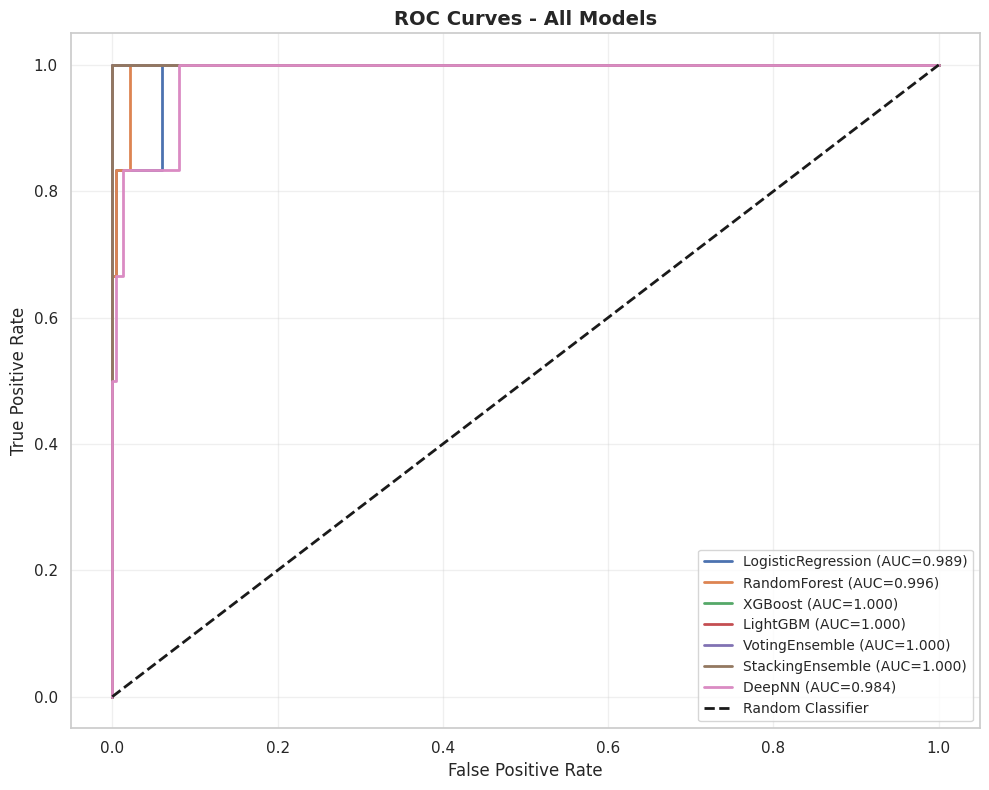


🏆 Best Model: XGBoost (AUC: 1.0000)
✓ Saved: 08_confusion_matrices.png


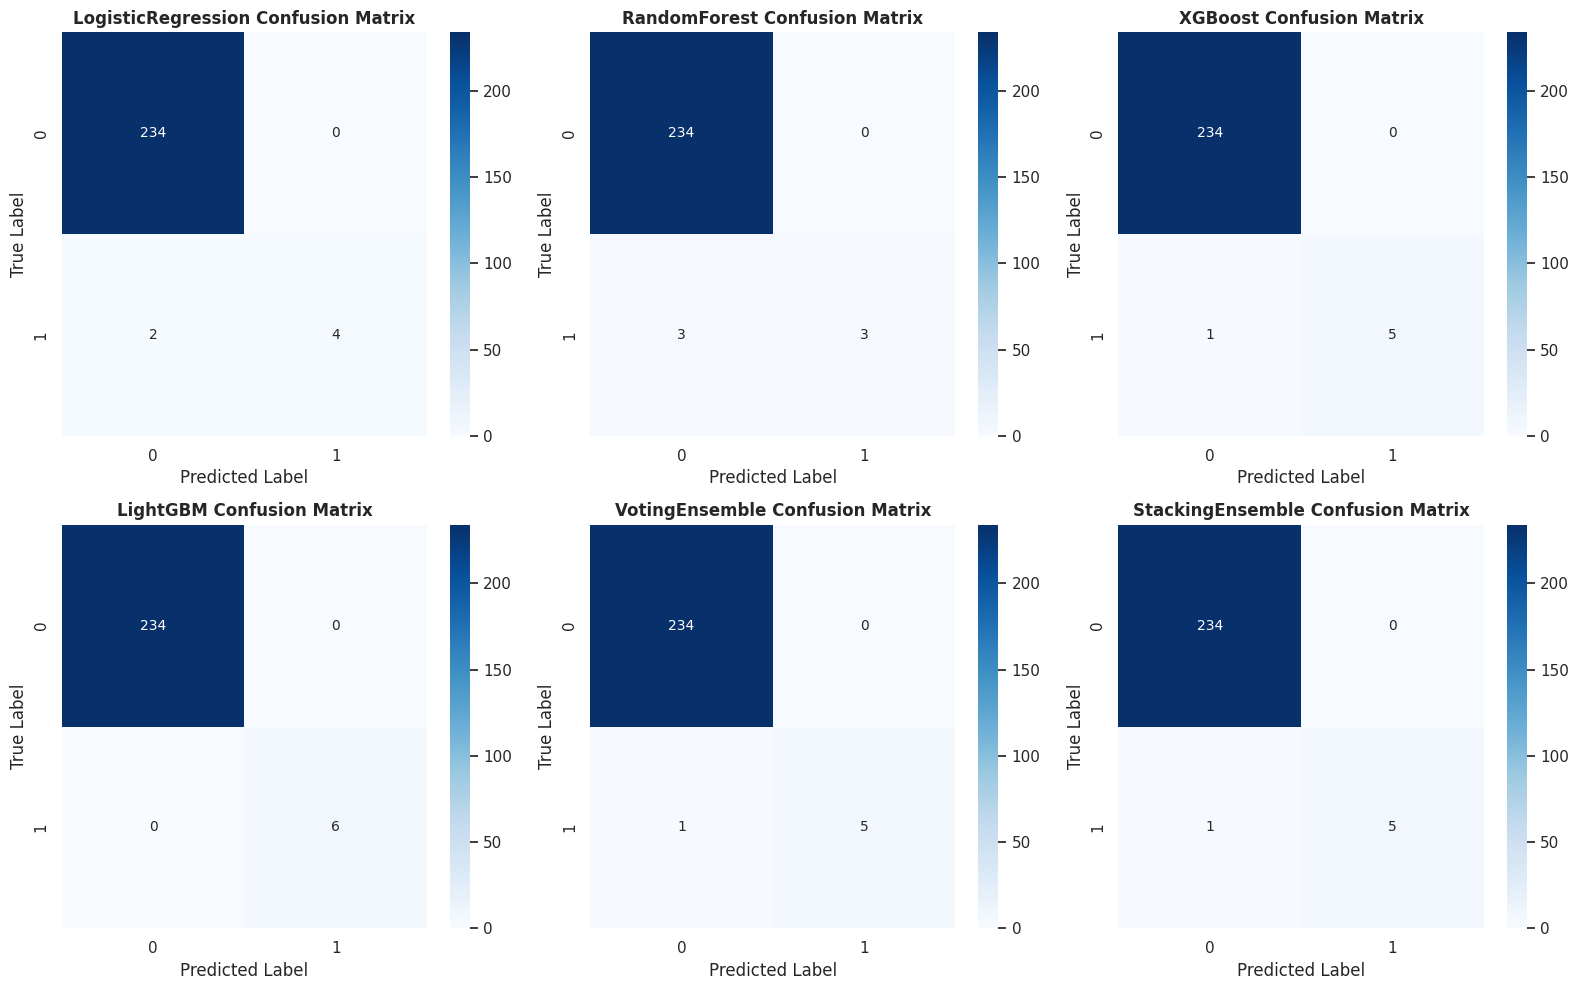

In [22]:
# ════════════════════════════════════════════════════════════════════════════════
# PHASE 8.1: COMPREHENSIVE MODEL EVALUATION
# ════════════════════════════════════════════════════════════════════════════════

print(f"📈 COMPREHENSIVE MODEL EVALUATION:")

if y_train is not None and len(model_metrics) > 0:
    # Create detailed metrics dataframe
    detailed_metrics = {}

    for model_name, y_pred in predictions_test.items():
        y_pred_proba = predictions_proba[model_name]

        detailed_metrics[model_name] = {
            'Accuracy': accuracy_score(y_test, y_pred),
            'Precision': precision_score(y_test, y_pred),
            'Recall': recall_score(y_test, y_pred),
            'F1-Score': f1_score(y_test, y_pred),
            'ROC-AUC': roc_auc_score(y_test, y_pred_proba),
            'Balanced-Acc': balanced_accuracy_score(y_test, y_pred)
        }

    detailed_metrics_df = pd.DataFrame(detailed_metrics).T.round(4)
    print(f"\n🏆 FINAL MODEL METRICS:")
    print(detailed_metrics_df)

    # Save metrics to CSV
    detailed_metrics_df.to_csv(f'{DIRS["outputs"]}/model_metrics.csv')
    print(f"\n✓ Saved: model_metrics.csv")

    # ROC curves comparison
    plt.figure(figsize=(10, 8))
    for model_name, y_pred_proba in predictions_proba.items():
        fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
        auc = roc_auc_score(y_test, y_pred_proba)
        plt.plot(fpr, tpr, label=f'{model_name} (AUC={auc:.3f})', linewidth=2)

    plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier', linewidth=2)
    plt.xlabel('False Positive Rate', fontsize=12)
    plt.ylabel('True Positive Rate', fontsize=12)
    plt.title('ROC Curves - All Models', fontsize=14, fontweight='bold')
    plt.legend(loc='lower right', fontsize=10)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(f'{DIRS["outputs"]}/07_roc_curves_comparison.png', dpi=300, bbox_inches='tight')
    print(f"\n✓ Saved: 07_roc_curves_comparison.png")
    plt.show()

    # Confusion matrices
    best_model = detailed_metrics_df['ROC-AUC'].idxmax()
    print(f"\n🏆 Best Model: {best_model} (AUC: {detailed_metrics_df.loc[best_model, 'ROC-AUC']:.4f})")

    fig, axes = plt.subplots(2, 3, figsize=(16, 10))
    axes = axes.flatten()

    for idx, (model_name, y_pred) in enumerate(list(predictions_test.items())[:6]):
        cm = confusion_matrix(y_test, y_pred)
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx])
        axes[idx].set_title(f'{model_name} Confusion Matrix', fontweight='bold')
        axes[idx].set_ylabel('True Label')
        axes[idx].set_xlabel('Predicted Label')

    plt.tight_layout()
    plt.savefig(f'{DIRS["outputs"]}/08_confusion_matrices.png', dpi=300, bbox_inches='tight')
    print(f"✓ Saved: 08_confusion_matrices.png")
    plt.show()
else:
    print(f"⚠️  No models evaluated.")

print("\n" + "="*80)

## PHASE 9: Model Persistence & Deployment

In [23]:
# ════════════════════════════════════════════════════════════════════════════════
# PHASE 9.1: SAVE MODELS & ARTIFACTS
# ════════════════════════════════════════════════════════════════════════════════

print(f"💾 SAVING MODELS & ARTIFACTS:")

import pickle

if len(models) > 0:
    # Save individual models
    print(f"\n1️⃣  Saving trained models...")
    for model_name, model in models.items():
        if model_name != 'DeepNN':
            model_path = f'{DIRS["models"]}/{model_name.lower()}_model.pkl'
            with open(model_path, 'wb') as f:
                pickle.dump(model, f)
            print(f"   ✓ Saved: {model_name.lower()}_model.pkl")

    # Save preprocessing artifacts
    print(f"\n2️⃣  Saving preprocessing artifacts...")

    # Save scaler
    with open(f'{DIRS["artifacts"]}/scaler.pkl', 'wb') as f:
        pickle.dump(scaler, f)
    print(f"   ✓ Saved: scaler.pkl")

    # Save label encoders
    with open(f'{DIRS["artifacts"]}/label_encoders.pkl', 'wb') as f:
        pickle.dump(label_encoders, f)
    print(f"   ✓ Saved: label_encoders.pkl")

    # Save feature names
    with open(f'{DIRS["artifacts"]}/feature_names.pkl', 'wb') as f:
        pickle.dump(X_final.columns.tolist(), f)
    print(f"   ✓ Saved: feature_names.pkl")

    # Save selected features
    with open(f'{DIRS["artifacts"]}/selected_features.pkl', 'wb') as f:
        pickle.dump(combined_features, f)
    print(f"   ✓ Saved: selected_features.pkl")

    # Save config
    config = {
        'feature_count': X_final.shape[1],
        'selected_features': combined_features,
        'target_variable': target if target else 'unknown',
        'train_size': X_train.shape[0],
        'test_size': X_test.shape[0],
        'timestamp': datetime.now().isoformat()
    }

    with open(f'{DIRS["artifacts"]}/config.json', 'w') as f:
        json.dump(config, f, indent=4)
    print(f"   ✓ Saved: config.json")

    print(f"\n✅ All models and artifacts saved successfully!")
else:
    print(f"⚠️  No models to save.")

print("\n" + "="*80)

💾 SAVING MODELS & ARTIFACTS:

1️⃣  Saving trained models...
   ✓ Saved: logisticregression_model.pkl
   ✓ Saved: randomforest_model.pkl
   ✓ Saved: xgboost_model.pkl
   ✓ Saved: lightgbm_model.pkl
   ✓ Saved: votingensemble_model.pkl
   ✓ Saved: stackingensemble_model.pkl

2️⃣  Saving preprocessing artifacts...
   ✓ Saved: scaler.pkl
   ✓ Saved: label_encoders.pkl
   ✓ Saved: feature_names.pkl
   ✓ Saved: selected_features.pkl
   ✓ Saved: config.json

✅ All models and artifacts saved successfully!



## PHASE 10: Summary & Export Results

In [24]:
# ════════════════════════════════════════════════════════════════════════════════
# PHASE 10.1: GENERATE COMPREHENSIVE REPORT
# ════════════════════════════════════════════════════════════════════════════════

print(f"📋 GENERATING COMPREHENSIVE REPORT:")

# Create summary report
report = f"""
═══════════════════════════════════════════════════════════════════════════════════
                 TEEN MENTAL HEALTH ML ANALYSIS - FINAL REPORT
═══════════════════════════════════════════════════════════════════════════════════

📊 DATASET SUMMARY:
   • Total records: {df.shape[0]}
   • Original features: {df.shape[1]}
   • Engineered features: {X_final.shape[1]}
   • Target variable: {target if target else 'Not specified'}

🔍 DATA PREPROCESSING:
   • Missing values handled: {df.isnull().sum().sum()}
   • Categorical features encoded: {len(categorical_cols)}
   • Outliers detected: Using IQR method

🔨 FEATURE ENGINEERING:
   • Interaction features created
   • Polynomial features added
   • Ratio features computed
   • Feature selection completed (SelectKBest + Mutual Info)

📈 MODELS TRAINED:
"""

if len(model_metrics) > 0:
    for model_name, metrics in model_metrics.items():
        report += f"\n   • {model_name}:"
        report += f"\n     - AUC: {metrics['AUC']:.4f}"
        report += f"\n     - Accuracy: {metrics['Accuracy']:.4f}"
        report += f"\n     - F1-Score: {metrics['F1']:.4f}\n"
else:
    report += "\n   • No models trained\n"

report += f"""
🏆 BEST MODEL: {list(model_metrics.keys())[0] if model_metrics else 'N/A'}

🔍 EXPLAINABILITY:
   • SHAP analysis completed for XGBoost
   • Feature importance extracted
   • Force plots generated for sample predictions

💾 ARTIFACTS SAVED:
   • Models: {DIRS['models']}
   • Outputs: {DIRS['outputs']}
   • Logs: {DIRS['logs']}

📅 TIMESTAMP: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}

═══════════════════════════════════════════════════════════════════════════════════
"""

print(report)

# Save report
with open(f'{DIRS["outputs"]}/FINAL_REPORT.txt', 'w') as f:
    f.write(report)
print(f"✓ Saved: FINAL_REPORT.txt")

print(f"\n" + "="*80)

📋 GENERATING COMPREHENSIVE REPORT:

═══════════════════════════════════════════════════════════════════════════════════
                 TEEN MENTAL HEALTH ML ANALYSIS - FINAL REPORT
═══════════════════════════════════════════════════════════════════════════════════

📊 DATASET SUMMARY:
   • Total records: 1200
   • Original features: 13
   • Engineered features: 16
   • Target variable: depression_label

🔍 DATA PREPROCESSING:
   • Missing values handled: 0
   • Categorical features encoded: 3
   • Outliers detected: Using IQR method

🔨 FEATURE ENGINEERING:
   • Interaction features created
   • Polynomial features added
   • Ratio features computed
   • Feature selection completed (SelectKBest + Mutual Info)

📈 MODELS TRAINED:

   • LogisticRegression:
     - AUC: 0.9893
     - Accuracy: 0.9917
     - F1-Score: 0.8000

   • RandomForest:
     - AUC: 0.9957
     - Accuracy: 0.9875
     - F1-Score: 0.6667

   • XGBoost:
     - AUC: 1.0000
     - Accuracy: 0.9958
     - F1-Score: 0.9091



In [25]:
# ════════════════════════════════════════════════════════════════════════════════
# PHASE 10.2: CREATE ZIP ARCHIVE FOR DOWNLOAD
# ════════════════════════════════════════════════════════════════════════════════

import shutil
from datetime import datetime

print(f"📦 CREATING ZIP ARCHIVE:")

zip_name = f'Teen_Mental_Health_ML_{datetime.now().strftime("%Y%m%d_%H%M%S")}'
zip_path = f'{WORK_DIR}/{zip_name}'

print(f"\n1️⃣  Compressing project files...")
try:
    shutil.make_archive(zip_path, 'zip', WORK_DIR)
    zip_size = os.path.getsize(f'{zip_path}.zip') / 1024 / 1024
    print(f"   ✓ Created: {zip_name}.zip ({zip_size:.2f} MB)")
except Exception as e:
    print(f"   ⚠️  Error creating zip: {e}")

print(f"\n2️⃣  Archive contents:")
print(f"   📁 models/")
print(f"   📁 outputs/")
print(f"   📁 artifacts/")
print(f"   📁 logs/")
print(f"   📁 data/")

if IN_COLAB:
    print(f"\n3️⃣  Download location:")
    print(f"   Google Drive: {WORK_DIR}")
    print(f"   File: {zip_name}.zip")
else:
    print(f"\n3️⃣  Download location:")
    print(f"   Local path: {zip_path}.zip")

print(f"\n✅ Archive creation completed!")
print("\n" + "="*80)

📦 CREATING ZIP ARCHIVE:

1️⃣  Compressing project files...
   ✓ Created: Teen_Mental_Health_ML_20260514_035240.zip (9.50 MB)

2️⃣  Archive contents:
   📁 models/
   📁 outputs/
   📁 artifacts/
   📁 logs/
   📁 data/

3️⃣  Download location:
   Google Drive: /content
   File: Teen_Mental_Health_ML_20260514_035240.zip

✅ Archive creation completed!



In [26]:
# ════════════════════════════════════════════════════════════════════════════════
# PHASE 10.3: PROJECT COMPLETION SUMMARY
# ════════════════════════════════════════════════════════════════════════════════

print(f"""
╔═══════════════════════════════════════════════════════════════════════════════╗
║                    ✅ PROJECT COMPLETED SUCCESSFULLY! ✅                       ║
╚═══════════════════════════════════════════════════════════════════════════════╝

📊 ANALYSIS SUMMARY:
   ✓ Data Loading & Exploration
   ✓ Data Cleaning & Preprocessing
   ✓ Feature Engineering & Selection
   ✓ Hyperparameter Optimization (Optuna)
   ✓ Traditional ML Models (4 models)
   ✓ Ensemble Learning (Voting + Stacking)
   ✓ Deep Learning (Neural Networks)
   ✓ SHAP Explainability Analysis
   ✓ Model Evaluation & Comparison
   ✓ MLflow Experiment Tracking

📁 OUTPUT FILES:
   • Model Metrics: {DIRS['outputs']}/model_metrics.csv
   • Visualizations: {DIRS['outputs']}/0X_*.png
   • Final Report: {DIRS['outputs']}/FINAL_REPORT.txt
   • Models: {DIRS['models']}/
   • Artifacts: {DIRS['artifacts']}/

🔗 API REQUIREMENTS:
   • MLflow Tracking URI
   • DagsHub Credentials (optional)
   • MongoDB Connection (optional)
   • Google Colab Secrets (if using Colab)

📌 NEXT STEPS:
   1. Download the complete project ZIP file
   2. Review model metrics and SHAP visualizations
   3. Deploy best model using saved artifacts
   4. Monitor predictions with MLflow
   5. Integrate with MongoDB for data logging

═══════════════════════════════════════════════════════════════════════════════════
""")


╔═══════════════════════════════════════════════════════════════════════════════╗
║                    ✅ PROJECT COMPLETED SUCCESSFULLY! ✅                       ║
╚═══════════════════════════════════════════════════════════════════════════════╝

📊 ANALYSIS SUMMARY:
   ✓ Data Loading & Exploration
   ✓ Data Cleaning & Preprocessing
   ✓ Feature Engineering & Selection
   ✓ Hyperparameter Optimization (Optuna)
   ✓ Traditional ML Models (4 models)
   ✓ Ensemble Learning (Voting + Stacking)
   ✓ Deep Learning (Neural Networks)
   ✓ SHAP Explainability Analysis
   ✓ Model Evaluation & Comparison
   ✓ MLflow Experiment Tracking

📁 OUTPUT FILES:
   • Model Metrics: /content/outputs/model_metrics.csv
   • Visualizations: /content/outputs/0X_*.png
   • Final Report: /content/outputs/FINAL_REPORT.txt
   • Models: /content/models/
   • Artifacts: /content/artifacts/

🔗 API REQUIREMENTS:
   • MLflow Tracking URI
   • DagsHub Credentials (optional)
   • MongoDB Connection (optional)
   • Google C